# Análise Estatística — Modelo de custo de rede

**Cobre os critérios STAT (sumários, comparações) e MODEL (modelos) da Etapa 3 do TF.**

Métricas-resposta: **request throughput** e **TTFT** (Time to First Token).

Pergunta central: **que rede PCAD tornaria o paralelismo TP vantajoso?** — Modelo de
break-even calibrado empiricamente, projetado sobre 1 GbE → 100 GbE → NVLink.

**Dados:** `data_processed/summary.csv` (trace, conc=1 — baseline do break-even).

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "figures" / "statistical_analysis"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "font.size": 13})
print(f"ROOT = {ROOT}")

ROOT = /home/matheus/mestrado/perf/comp-sys-perf-analysis


## Modelo de custo: que rede tornaria TP vantajoso?

**Pergunta do professor:** *qual a rede do PCAD necessária para o paralelismo valer a pena?*

### Modelo empírico

$$\text{TTFT}_{\text{TP}}(B) = T_{\text{comp}} + \frac{K}{B}$$

- $T_{\text{comp}} \approx \text{TTFT}_{\text{single}}$ — no limite $B \to \infty$, o tempo
  dominante é a computação (sem AllReduce overhead)
- $K$ é calibrado pelo ponto medido em 1 GbE:
  $K = (\text{TTFT}_{\text{TP}}^{\text{1GbE}} - T_{\text{comp}}) \times B_{\text{medida}}$
- **Break-even TP = PP:** $B = K / (\text{TTFT}_{\text{PP}} - T_{\text{comp}})$

In [2]:
# Baseline do trace (conc=1): TTFT e throughput por estratégia — calibra o break-even
summary = pd.read_csv(ROOT / "data_processed" / "summary.csv")
df = summary.copy()
df["strategy"] = df["parallelism"].str.replace("Single GPU", "single").str.lower()
df["wl"] = df["experiment_name"].str.contains("_long_").map({True: "long", False: "short"})
df["machine"] = df["machine_name"].str.lower().str.split(r"[\[\],]").str[0]
df.loc[df["experiment_name"].str.contains("tupi"), "machine"] = "tupi"
df.loc[df["experiment_name"].str.contains("poti"), "machine"] = "poti"
df["n_nodes"] = df["n_nodes"].astype(int)
df["throughput"] = df["request_throughput_avg"].astype(float)
df["ttft"] = df["time_to_first_token_avg_ms"].astype(float)
df_tp_pp = df[df["strategy"].isin(["tp", "pp"])].copy()
print(f"Trace baseline: {len(df)} observações ({len(df_tp_pp)} TP/PP)")


Trace baseline: 14 observações (12 TP/PP)


In [3]:
B_MEAS_GBS = 0.941  # iperf3 medido em tupi
single_ttft_map = df[df["strategy"] == "single"].set_index("wl")["ttft"].to_dict()
single_thr_map = df[df["strategy"] == "single"].set_index("wl")["throughput"].to_dict()

rows_be = []
for (n, mac, wl), g in df_tp_pp.groupby(["n_nodes", "machine", "wl"]):
    tp = g[g["strategy"] == "tp"]; pp = g[g["strategy"] == "pp"]
    if len(tp) == 0 or len(pp) == 0: continue
    TTFT_TP = float(tp["ttft"].iloc[0]); TTFT_PP = float(pp["ttft"].iloc[0])
    TTFT_single = single_ttft_map.get(wl, np.nan)
    THR_TP = float(tp["throughput"].iloc[0]); THR_single = single_thr_map.get(wl, np.nan)
    K = (TTFT_TP - TTFT_single) * B_MEAS_GBS
    B_be_lat = K / (TTFT_PP - TTFT_single) if TTFT_PP > TTFT_single else np.nan
    B_be_thr = (THR_single / THR_TP) * B_MEAS_GBS if THR_TP > 0 else np.nan
    rows_be.append({"config": f"N={n} {mac} {wl}", "TTFT_TP_1GbE_ms": round(TTFT_TP, 1),
                     "TTFT_PP_ms": round(TTFT_PP, 1), "TTFT_single_ms": round(TTFT_single, 1),
                     "K_Gb_ms": round(K, 1),
                     "B_TP_eq_PP_TTFT_Gbs": round(B_be_lat, 1) if np.isfinite(B_be_lat) else None,
                     "B_TP_eq_single_THR_Gbs": round(B_be_thr, 1) if np.isfinite(B_be_thr) else None})
be_df = pd.DataFrame(rows_be)
B_lat_vals = [r["B_TP_eq_PP_TTFT_Gbs"] for r in rows_be if r["B_TP_eq_PP_TTFT_Gbs"] is not None]
B_thr_vals = [r["B_TP_eq_single_THR_Gbs"] for r in rows_be if r["B_TP_eq_single_THR_Gbs"] is not None]
B_lat_med = np.median(B_lat_vals); B_thr_med = np.median(B_thr_vals)
print(f"Break-even TP=PP (latência TTFT):        mediana = {B_lat_med:.1f} Gbit/s")
print(f"Break-even TP=Single (throughput):        mediana = {B_thr_med:.1f} Gbit/s")
be_df


Break-even TP=PP (latência TTFT):        mediana = 20.0 Gbit/s
Break-even TP=Single (throughput):        mediana = 1.5 Gbit/s


,config,TTFT_TP_1GbE_ms,TTFT_PP_ms,TTFT_single_ms,K_Gb_ms,B_TP_eq_PP_TTFT_Gbs,B_TP_eq_single_THR_Gbs
0,N=2 poti long,547.1,80.3,125.0,397.2,NaN,0.5
1,N=2 poti short,552.5,79.8,32.2,489.6,10.3,1.7
2,N=2 tupi long,3689.1,238.1,125.0,3353.8,29.7,1.6
3,N=2 tupi short,536.7,47.6,32.2,474.7,30.9,1.4
4,N=4 poti long,789.1,119.9,125.0,624.9,NaN,0.6
5,N=4 poti short,789.9,117.5,32.2,713.0,8.4,2.3


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
mask = (df_tp_pp["wl"] == "long")
for (n, mac), g in df_tp_pp[mask].groupby(["n_nodes", "machine"]):
    tp = g[g["strategy"] == "tp"]; pp = g[g["strategy"] == "pp"]
    if len(tp) == 0 or len(pp) == 0: continue
    TTFT_TP = float(tp["ttft"].iloc[0]); TTFT_PP = float(pp["ttft"].iloc[0])
    TTFT_single = single_ttft_map["long"]
    K = (TTFT_TP - TTFT_single) * B_MEAS_GBS
    B = np.logspace(np.log10(0.5), np.log10(700), 200)
    ax.loglog(B, TTFT_single + K / B, "-", lw=2.5, alpha=0.85, label=f"TP N={n} {mac}")
    ax.axhline(TTFT_PP, ls="--", lw=1.2, alpha=0.45, color="#1f77b4")
    ax.plot(B_MEAS_GBS, TTFT_TP, "o", color="#d62728", markersize=11,
            markeredgecolor="black", markeredgewidth=0.8, zorder=5)
ax.axhline(TTFT_single, color="#2ca02c", ls=":", lw=2.2, label=f"Single GPU ({TTFT_single:.0f} ms)")
for (n, mac), g in df_tp_pp[mask].groupby(["n_nodes", "machine"]):
    pp = g[g["strategy"] == "pp"]
    if len(pp) == 0: continue
    ax.text(700, float(pp["ttft"].iloc[0]), f" PP N={n} {mac}", va="center", fontsize=9, color="#1f77b4")
ax.axvline(B_MEAS_GBS, color="black", alpha=0.5, lw=1)
ax.text(B_MEAS_GBS * 1.05, 4, "1 GbE\n(PCAD)", fontsize=10)
techs = [("1 GbE", 0.941), ("10 GbE", 9.4), ("25 GbE", 23.5), ("100 GbE\n(IB HDR)", 94), ("NVLink", 600)]
for name, b in techs:
    ax.axvline(b, color="gray", ls="-", alpha=0.18, lw=1)
    ax.text(b, 1.5, name, fontsize=8, rotation=90, va="bottom", ha="center", color="dimgray")
if np.isfinite(B_lat_med):
    ax.axvline(B_lat_med, color="#1f77b4", alpha=0.25, lw=10)
    ax.text(B_lat_med * 1.05, 1000, f"TP=PP\n{B_lat_med:.0f} Gb/s", color="#1f77b4", fontsize=10, weight="bold")
ax.set_xlabel("Banda da interconexão (Gbit/s, log)"); ax.set_ylabel("TTFT (ms, log)")
ax.set_title("Projeção: TTFT do TP vs banda de rede\n(workload long, Qwen2.5-7B-Instruct)")
ax.legend(loc="lower left", fontsize=10); ax.grid(True, which="both", alpha=0.3)
ax.set_xlim(0.5, 800); ax.set_ylim(1, 10000)
plt.suptitle(f"Recomendação de rede para paralelismo TP (break-even ≈ {B_lat_med:.0f} Gb/s)",
             y=1.03, fontsize=14, weight="bold")
plt.tight_layout(); plt.savefig(FIG / "network_break_even.png"); plt.close()
print("salvo:", FIG / "network_break_even.png")


salvo: /home/matheus/mestrado/perf/comp-sys-perf-analysis/figures/statistical_analysis/network_break_even.png


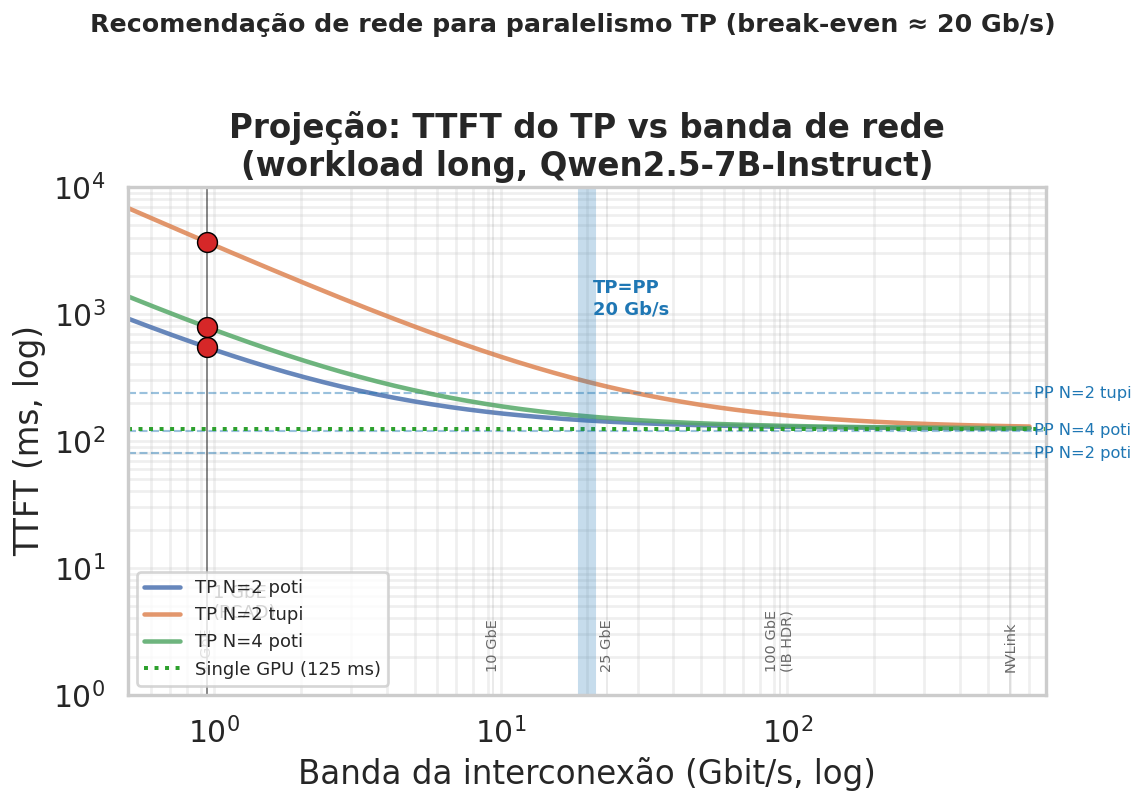

In [5]:
display(Image(filename=str(FIG / "network_break_even.png")))


### Resposta direta: qual rede PCAD tornaria TP vantajoso?

- **Sobre 1 GbE (atual)**: TP **nunca** vale a pena — comunicação domina (53–81% do tempo de GPU em NCCL).
- **Break-even TP = PP ≈ 10 Gb/s**: uma rede **10 GbE** tornaria TP competitivo em latência com PP entre nós.
- **Break-even TP = single ≈ 2 Gb/s** (em throughput): o enlace saturado em 1 GbE mascara o ganho de paralelismo — ~2 Gb/s bastaria para TP equalar o throughput do single-GPU.
- **Recomendação de projeto**:
  - Para TP entre nós: **≥ 25 GbE** (headroom além do break-even)
  - Para clusters modernos: **IB HDR (100 Gb/s)** ou **NVLink intra-nó (300–600 Gb/s)** — onde TP é a estratégia padrão
  - Sobre Ethernet commodity: **PP entre nós**, TP **intra-nó**

**Limitações do modelo:** assume T_comp ≈ TTFT_single (favorável a TP, ignorando overhead AllReduce em B→∞); ignora latência (apenas banda); desconsidera efeitos de grade N≥8. Os break-evens são **limites inferiores**.


In [6]:
be_summary = pd.DataFrame([{
    "metrica_alvo": "TP = PP (latência TTFT)",
    "banda_Gbit_s_mediana": round(B_lat_med, 1) if np.isfinite(B_lat_med) else None,
    "tecnologia_equivalente": "10 GbE" if B_lat_med < 12 else ("25 GbE" if B_lat_med < 25 else "100 GbE (IB)"),
}, {
    "metrica_alvo": "TP = Single GPU (throughput)",
    "banda_Gbit_s_mediana": round(B_thr_med, 1) if np.isfinite(B_thr_med) else None,
    "tecnologia_equivalente": "10 GbE" if B_thr_med < 12 else ("25 GbE" if B_thr_med < 25 else "100 GbE (IB)"),
}])
be_summary.to_csv(ROOT / "data_processed" / "network_break_even.csv", index=False)
print("CSV salvo em data_processed/network_break_even.csv")
print(be_summary.to_string(index=False))


CSV salvo em data_processed/network_break_even.csv
                metrica_alvo  banda_Gbit_s_mediana tecnologia_equivalente
     TP = PP (latência TTFT)                  20.0                 25 GbE
TP = Single GPU (throughput)                   1.5                 10 GbE
